# Gestion des environnements virtuels par projet (avec `uv`)

## Constat de départ

Jusqu'ici, tous les projets sous `D:\DATA\Projets` partageaient **un seul venv géant** (`.Env_NC_Global`, ~2.2 Go, ~95 packages : tensorflow, mne, xgboost, shap, umap...) référencé globalement dans `D:\DATA\Projets\.vscode\settings.json`. Problème : chaque projet traîne des dépendances qu'il n'utilise pas, les montées de version d'un projet peuvent casser un autre, et l'environnement devient de moins en moins reproductible.

**Objectif** : un venv **par projet**, minimal et complété au fil des besoins réels, sans exploser le temps de création ni l'espace disque.

## Pourquoi `uv`

`uv` (déjà installé : `D:\DATA\Projets\Python313\Scripts\uv.exe`) résout les deux contraintes à la fois :

- **Vitesse** : résolveur de dépendances écrit en Rust, installation parallèle, quasi instantané une fois le cache chaud.
- **Espace disque** : tous les packages téléchargés vivent une seule fois dans un **cache global** (`uv cache dir`). Chaque venv ne fait que des **hardlinks** vers ce cache — donc si 10 projets utilisent `numpy==2.5.0`, il n'est stocké qu'**une seule fois** physiquement sur le disque, même si chaque projet a son propre `.venv` isolé.

⚠️ **Piège découvert en configurant ce projet** : le cache `uv` était par défaut sur `C:` (`AppData\Local\uv\cache`) alors que tous les projets sont sur `D:`. Les hardlinks ne fonctionnent qu'au sein d'un **même volume** — `uv` retombait donc silencieusement sur des copies complètes (`Failed to hardlink files; falling back to full copy`), annulant le gain d'espace. Correction appliquée : variable d'environnement persistante

```
UV_CACHE_DIR = D:\DATA\.uv_cache
```

(faite via `setx`, donc active dans tous les futurs terminaux/VSCode). À vérifier de temps en temps que le cache ne dérive pas ailleurs (`uv cache dir`).

## Structure type d'un projet

```
MonProjet/
├── .venv/            # créé par uv, jamais commité (dans .gitignore)
├── pyproject.toml    # liste des dépendances du projet
├── uv.lock           # versions exactes, pour reproductibilité
└── .python-version    # version Python fixée pour ce projet
```

## Commandes essentielles

| Commande | Effet |
|---|---|
| `uv init --no-readme` | Initialise `pyproject.toml` dans un dossier existant (sans écraser un README déjà présent) |
| `uv add numpy pandas ...` | Ajoute des dépendances (crée le `.venv` si besoin, met à jour `pyproject.toml` + `uv.lock`) |
| `uv remove <pkg>` | Retire une dépendance |
| `uv sync` | Recrée/synchronise `.venv` à partir de `uv.lock` (ex: après un `git clone`) |
| `uv run <script>.py` | Exécute dans le venv du projet sans l'activer manuellement |
| `uv cache dir` / `uv cache clean` | Localiser / vider le cache global |

Pas besoin de `pip install`, ni d'activer manuellement le venv (`uv run` s'en charge) — mais l'activation classique (`.venv\Scripts\activate`) reste possible si un outil tiers l'exige.

## Intégration VSCode / Jupyter

Deux cas différents :

- **Notebooks (`.ipynb`)** : le kernel est choisi **par notebook** (bouton en haut à droite), indépendamment des réglages globaux du workspace. On enregistre le venv du projet comme kernel Jupyter une fois :
  ```
  uv add --dev ipykernel
  uv run python -m ipykernel install --user --name <nom_projet> --display-name "<NomProjet> (uv)"
  ```
  Ensuite il suffit de sélectionner `<NomProjet> (uv)` dans le sélecteur de kernel de chaque notebook du projet.

- **Scripts `.py`** : l'extension Python de VSCode choisit un interpréteur **par dossier racine de workspace**. Comme `D:\DATA\Projets` est ouvert comme un unique workspace racine contenant tous les projets (`.vscode/settings.json` global), un `.venv` local à un sous-dossier n'est **pas auto-détecté**. Deux options :
  1. Ouvrir le projet individuellement comme son propre dossier VSCode (`File > Open Folder`) → le `.venv` local est alors auto-détecté et proposé.
  2. Sélectionner manuellement l'interpréteur (`Ctrl+Shift+P` → *Python: Select Interpreter* → *Enter interpreter path* → `<projet>\.venv\Scripts\python.exe`) — VSCode retient ce choix par dossier ouvert.

## Exemple concret appliqué à ce projet (`Test_Git`)

```
cd D:\DATA\Projets\Test_Git
uv init --no-readme --python 3.13
uv add numpy pandas statsmodels seaborn scikit-learn ipykernel
uv run python -m ipykernel install --user --name test_git --display-name "Test_Git (uv)"
```

Résultat : `.venv` local (~340 Mo apparents, mais physiquement partagé via hardlinks avec le cache global dès qu'un autre projet réutilise les mêmes versions), `pyproject.toml` + `uv.lock` commités, `.venv` ignoré par git. Kernel `Test_Git (uv)` disponible dans le sélecteur de ce notebook.

**Prochaine étape** : sélectionner le kernel `Test_Git (uv)` pour ce notebook (au lieu du `.Env_NC_Global` actuel), puis répéter le pattern sur les autres projets au fur et à mesure, en n'ajoutant que les packages réellement utilisés par chacun.


<Axes: >

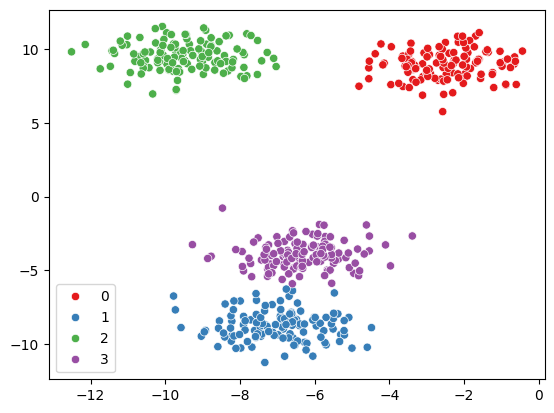

In [ ]:
import numpy as np  
import pandas as pd
import statsmodels.api as sm
import seaborn as sns

from sklearn.datasets import make_blobs

X, y = make_blobs(
    n_samples=1000,       # nombre de points
    centers=4,           # nombre de clusters (ou liste de coordonnées)
    n_features=3,        # dimension des données
    cluster_std=1.0,     # écart-type de chaque cluster (float ou liste par cluster)
    center_box=(-10, 10),# bornes pour générer les centres aléatoirement
    random_state=42      # reproductibilité
)

sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='Set1')

# test de la branche